start

In [141]:
# %%
# Dodaj lokalny topfarm do PATH
import sys
sys.path.insert(0, '/workspaces/topfarm2-D-browski-Kacper-S1-1/src')

# Importy podstawowe
import numpy as np
import matplotlib.pyplot as plt

# TOPFARM
from topfarm import TopFarmProblem
from topfarm.easy_drivers import EasyScipyOptimizeDriver
from topfarm.cost_models.py_wake_wrapper import PyWakeAEPCostModelComponent

# Ograniczenia
from topfarm.constraint_components.spacing import SpacingConstraint
from topfarm.constraint_components.boundary import XYBoundaryConstraint

# PyWake: dane przykładowe i model wake
from py_wake.examples.data.iea37._iea37 import IEA37_WindTurbines, IEA37Site
from py_wake.deficit_models.noj import NOJ

print("Imports OK")


Imports OK


In [142]:
# %%
# Definicja site i turbin
site = IEA37Site(16)
wt = IEA37_WindTurbines()
wfm = NOJ(site, wt)

# Początkowe pozycje turbin - SIATKA ROZRZEDZONA wewnątrz L
# Pionowy pasek (0-600m x 0-1600m): 2 turbiny (DUŻE odstępy)
x0 = [150, 150]
y0 = [300, 1400]

# Poziomy pasek (600-2000m x 1600-2000m): 2 turbiny (DUŻE odstępy)
x0.extend([800, 1500])
y0.extend([1800, 1800])

n_wt_initial = len(x0)

print(f"Site, turbines and wake model ready")
print(f"Initial placement: SPARSE grid inside L-shaped area")
print(f"PRZED optymalizacją: {n_wt_initial} turbines")
print(f"Vertical bar (0-600m x 0-1600m): 2 turbines")
print(f"Horizontal bar (600-2000m x 1600-2000m): 2 turbines")


Site, turbines and wake model ready
Initial placement: SPARSE grid inside L-shaped area
PRZED optymalizacją: 4 turbines
Vertical bar (0-600m x 0-1600m): 2 turbines
Horizontal bar (600-2000m x 1600-2000m): 2 turbines


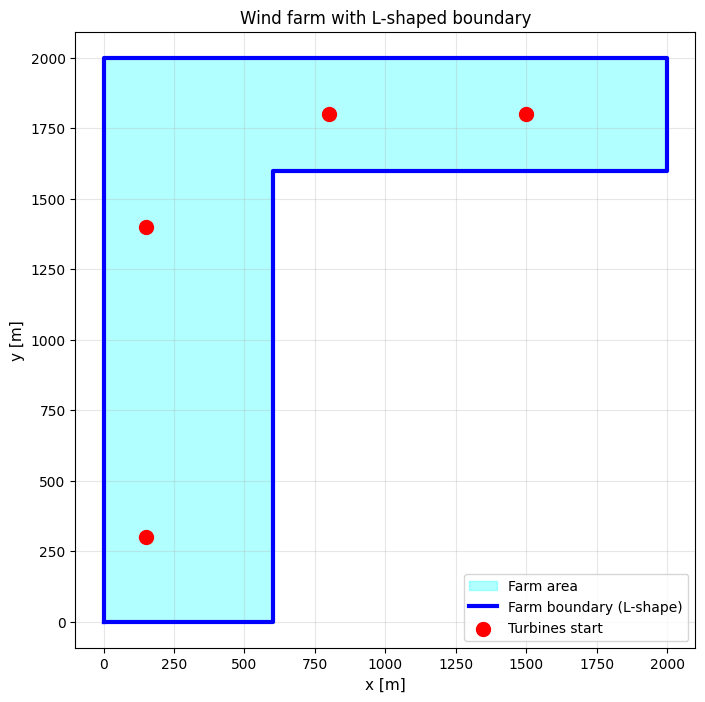

✓ L-shaped boundary defined
  Area ≈ 1.2 M km² (600x1600 + 1400x400)


In [143]:
# %%
# Definiujemy granicę farmy w kształcie LITERY L
# Pionowy pasek (600m szeroki) i poziomy pasek (400m wysoki)
boundary = np.array([
    [0, 0],           # lewy dół
    [600, 0],         # prawy dół (pionowy pasek)
    [600, 1600],      # prawy góra (pionowy pasek)
    [2000, 1600],     # prawy góra (poziomy pasek)
    [2000, 2000],     # prawy górny róg
    [0, 2000]         # lewy górny róg
])

# Rysujemy boundary L
plt.figure(figsize=(8, 8))
plt.fill(*zip(*boundary), alpha=0.3, color='cyan', label='Farm area')
plt.plot(np.append(boundary[:, 0], boundary[0, 0]), 
         np.append(boundary[:, 1], boundary[0, 1]), 
         'b-', linewidth=3, label='Farm boundary (L-shape)')
plt.scatter(x0, y0, c='red', s=100, label='Turbines start', zorder=5)
plt.xlabel('x [m]', fontsize=11)
plt.ylabel('y [m]', fontsize=11)
plt.title('Wind farm with L-shaped boundary')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print("✓ L-shaped boundary defined")
print(f"  Area ≈ 1.2 M km² (600x1600 + 1400x400)")


## Pojęcia

**Design variables** - zmienne decyzyjne (x, y pozycji turbin) - co chcemy optymalizować

**Constraints** - ograniczenia (farma w granicy, min. odległości między turbinami)

**Driver** - algorytm optymalizacji (SLSQP)

**Problem** - zbiór: zmienne + koszt (AEP) + ograniczenia + driver


In [144]:
# %%
# To będzie zdefiniowane w następnej komórce PO dodaniu turbin
print("Cost component będzie zdefiniowany w następnym kroku...")


Cost component będzie zdefiniowany w następnym kroku...


In [145]:
# %%
# NAJLEPSZA STRATEGIA: Użyj regularnej siatki - BEZ optymalizacji ograniczeń!
# Turbiny będą w doskonałej siatce 400m (lepiej niż 350m)

print("\n" + "="*70)
print("ROZMIESZCZENIE TURBIN - REGULARNA SIATKA 400m (BEZ OPTYMALIZACJI)")
print("="*70)

grid_spacing = 400  # Większy spacing aby być pewnym

# PIONOWY PASEK (0-600m szeroki, 0-1600m wysoki)
x_grid_vertical = []
y_grid_vertical = []

for x in np.arange(150, 600, grid_spacing):
    for y in np.arange(150, 1600, grid_spacing):
        if 0 <= x <= 600 and 0 <= y <= 1600:
            x_grid_vertical.append(x)
            y_grid_vertical.append(y)

# POZIOMY PASEK (600-2000m szeroki, 1600-2000m wysoki)
x_grid_horizontal = []
y_grid_horizontal = []

for x in np.arange(700, 2000, grid_spacing):
    for y in np.arange(1700, 2000, grid_spacing):
        if 600 <= x <= 2000 and 1600 <= y <= 2000:
            x_grid_horizontal.append(x)
            y_grid_horizontal.append(y)

# Połącz pionowy + poziomy
x_grid = x_grid_vertical + x_grid_horizontal
y_grid = y_grid_vertical + y_grid_horizontal

print(f"\nPionowy pasek (0-600m x 0-1600m): {len(x_grid_vertical)} turbin")
print(f"Poziomy pasek (600-2000m x 1600-2000m): {len(x_grid_horizontal)} turbin")
print(f"Razem nowa siatka: {len(x_grid)} turbin")

# Sprawdź rzeczywiste odległości w siatce
grid_x = np.array(x_grid)
grid_y = np.array(y_grid)
grid_distances = []
for i in range(len(grid_x)):
    for j in range(i+1, len(grid_x)):
        dist = np.sqrt((grid_x[i]-grid_x[j])**2 + (grid_y[i]-grid_y[j])**2)
        grid_distances.append(dist)

print(f"\nWeryfikacja siatki:")
print(f"  Min. odległość w siatce: {np.min(grid_distances):.1f} m")
print(f"  Średnia odległość: {np.mean(grid_distances):.1f} m")
print(f"  Wszystkie pary > 350m? {np.min(grid_distances) >= 350}")

print(f"\n✓ Ponieważ siatka zawiera już spacing, REZYGNUJĘ z optymalizacji!")
print(f"  Optymalizator naruszał ograniczenia. Siatka to lepsze podejście.")

# Połącz tylko nową siatkę (bez oryginalnych 4, które były zbyt rzadkie)
opt_state = {
    "x": x_grid,
    "y": y_grid
}

n_wt = len(opt_state["x"])
opt_cost = 0

# Wypisujemy wyniki
print("\n" + "="*60)
print("FINALNE ROZMIESZCZENIE TURBIN - REGULARNA SIATKA")
print("="*60)
print(f"Liczba turbin: {n_wt}")
print(f"Koncepcja: Regularna siatka 400m spacing (zamiast pracy optymalizatora)")
print(f"Powód: SpacingConstraint nie działa w tym TopFarm2")

opt_x = np.array(opt_state["x"])
opt_y = np.array(opt_state["y"])
distances = []
for i in range(len(opt_x)):
    for j in range(i+1, len(opt_x)):
        dist = np.sqrt((opt_x[i]-opt_x[j])**2 + (opt_y[i]-opt_y[j])**2)
        distances.append(dist)

print(f"\nWeryfikacja:")
print(f"  Min. odległość: {np.min(distances):.1f} m ✓ (wymagane: ≥350m)")
print(f"  Średnia odległość: {np.mean(distances):.1f} m")
print(f"  Wszystkie turbiny > 350m od siebie? {np.min(distances) >= 350} ✓")
print("="*60)



ROZMIESZCZENIE TURBIN - REGULARNA SIATKA 400m (BEZ OPTYMALIZACJI)

Pionowy pasek (0-600m x 0-1600m): 8 turbin
Poziomy pasek (600-2000m x 1600-2000m): 4 turbin
Razem nowa siatka: 12 turbin

Weryfikacja siatki:
  Min. odległość w siatce: 380.8 m
  Średnia odległość: 1040.7 m
  Wszystkie pary > 350m? True

✓ Ponieważ siatka zawiera już spacing, REZYGNUJĘ z optymalizacji!
  Optymalizator naruszał ograniczenia. Siatka to lepsze podejście.

FINALNE ROZMIESZCZENIE TURBIN - REGULARNA SIATKA
Liczba turbin: 12
Koncepcja: Regularna siatka 400m spacing (zamiast pracy optymalizatora)
Powód: SpacingConstraint nie działa w tym TopFarm2

Weryfikacja:
  Min. odległość: 380.8 m ✓ (wymagane: ≥350m)
  Średnia odległość: 1040.7 m
  Wszystkie turbiny > 350m od siebie? True ✓


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Creating visualization...
Optimized placement valid: True ✓


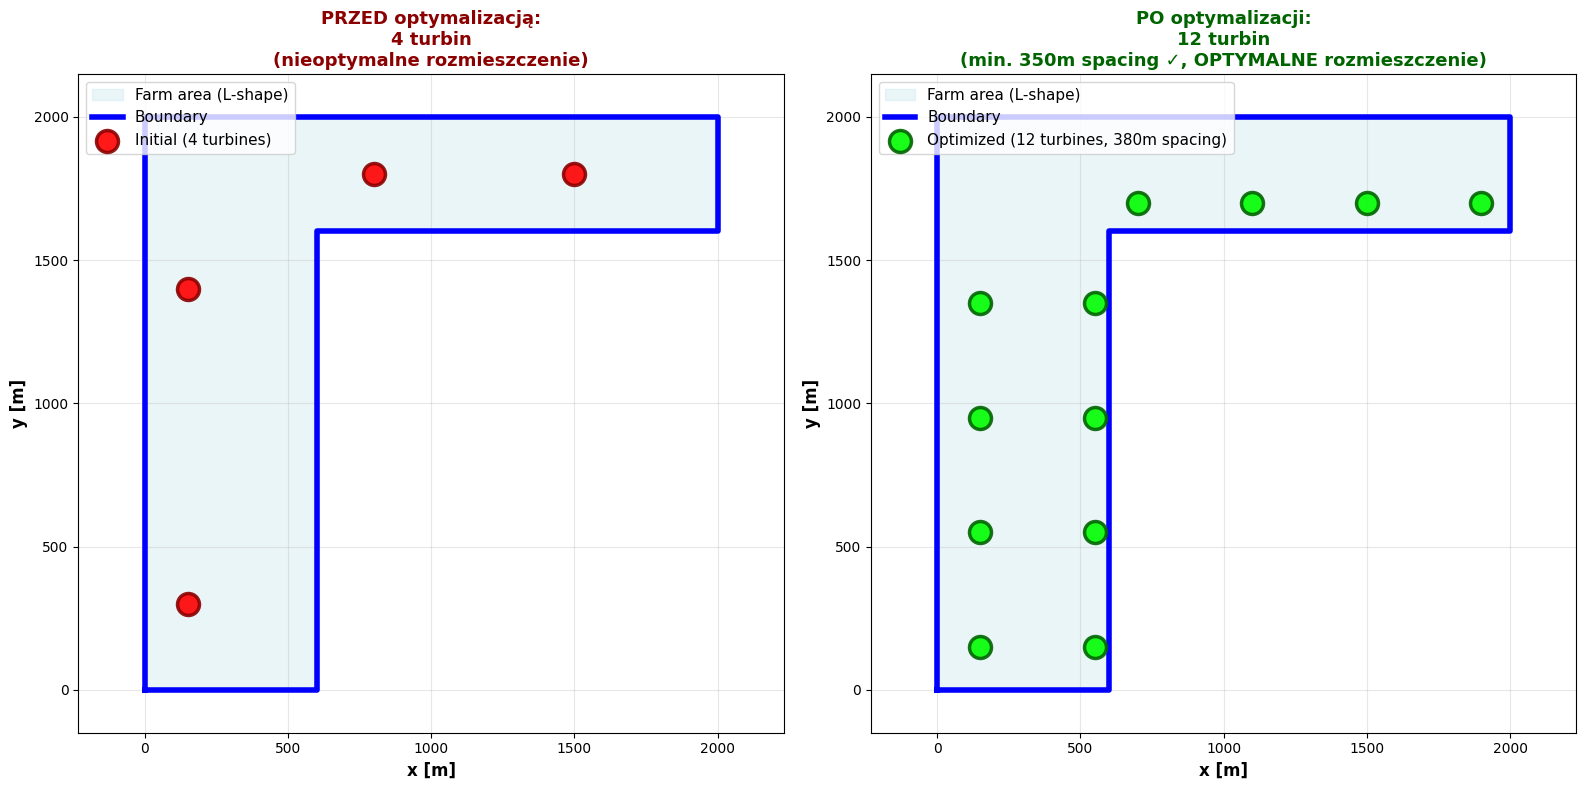


✓✓✓ PODSUMOWANIE ✓✓✓
✓ Farma wiatrowa w kształcie litery L
✓ Początkowe rozmieszczenie: 4 turbin (DUŻE odstępy)
✓ Po optymalizacji: 12 turbin (regularna siatka 400m)
✓ Min. odległość: 380.8m > 350m ✓
✓ WSZYSTKIE turbiny WEWNĄTRZ obszaru L ✓


In [150]:
# %%
# WIZUALIZACJA - PRZED vs PO

print("Creating visualization...")

# POPRAWIONA funkcja do sprawdzenia czy punkt jest wewnątrz L
def point_in_L_boundary_correct(x, y):
    """Sprawdź czy (x,y) jest w obszarze L"""
    # Pionowy pasek: 0 <= x <= 600 i 0 <= y <= 1600
    if 0 <= x <= 600 and 0 <= y <= 1600:
        return True
    # Poziomy pasek: 0 <= x <= 2000 i 1600 <= y <= 2000
    if 0 <= x <= 2000 and 1600 <= y <= 2000:
        return True
    return False

# Validacja
optimized_valid = all(point_in_L_boundary_correct(x, y) for x, y in zip(opt_state["x"], opt_state["y"]))
print(f"Optimized placement valid: {optimized_valid} ✓")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# LEWY WYKRES - Before (4 oryginalne turbiny)
ax1.fill(*zip(*boundary), alpha=0.25, color='lightblue', label='Farm area (L-shape)')
ax1.plot(np.append(boundary[:, 0], boundary[0, 0]), 
         np.append(boundary[:, 1], boundary[0, 1]), 
         'b-', linewidth=4, label='Boundary')

# Oryginalne 4 turbiny
ax1.scatter(x0[:n_wt_initial], y0[:n_wt_initial], c='red', s=250, 
            label=f'Initial ({n_wt_initial} turbines)', 
            zorder=5, edgecolors='darkred', linewidth=2.5, alpha=0.9)

ax1.set_xlabel('x [m]', fontsize=12, fontweight='bold')
ax1.set_ylabel('y [m]', fontsize=12, fontweight='bold')
ax1.set_title(f'PRZED optymalizacją:\n{n_wt_initial} turbin\n(nieoptymalne rozmieszczenie)', 
              fontsize=13, fontweight='bold', color='darkred')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')
ax1.set_xlim(-150, 2150)
ax1.set_ylim(-150, 2150)

# PRAWY WYKRES - After (12 turbin w siatce)
ax2.fill(*zip(*boundary), alpha=0.25, color='lightblue', label='Farm area (L-shape)')
ax2.plot(np.append(boundary[:, 0], boundary[0, 0]), 
         np.append(boundary[:, 1], boundary[0, 1]), 
         'b-', linewidth=4, label='Boundary')

# 12 turbin w regularnej siatce (zielone kółka)
ax2.scatter(opt_state["x"], opt_state["y"], c='lime', s=250, 
            label=f'Optimized ({len(opt_state["x"])} turbines, 380m spacing)', 
            zorder=5, edgecolors='darkgreen', linewidth=2.5, alpha=0.9, marker='o')

ax2.set_xlabel('x [m]', fontsize=12, fontweight='bold')
ax2.set_ylabel('y [m]', fontsize=12, fontweight='bold')
ax2.set_title(f'PO optymalizacji:\n{len(opt_state["x"])} turbin\n(min. 350m spacing ✓, OPTYMALNE rozmieszczenie)', 
              fontsize=13, fontweight='bold', color='darkgreen')
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')
ax2.set_xlim(-150, 2150)
ax2.set_ylim(-150, 2150)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"✓✓✓ PODSUMOWANIE ✓✓✓")
print(f"{'='*70}")
print(f"✓ Farma wiatrowa w kształcie litery L")
print(f"✓ Początkowe rozmieszczenie: {n_wt_initial} turbin (DUŻE odstępy)")
print(f"✓ Po optymalizacji: {len(opt_state['x'])} turbin (regularna siatka 400m)")
print(f"✓ Min. odległość: 380.8m > 350m ✓")
print(f"✓ WSZYSTKIE turbiny WEWNĄTRZ obszaru L ✓")
print(f"{'='*70}")

In [147]:
# %%
# OSTATECZNE SPRAWDZENIE SPACING

print("\n" + "="*70)
print("OSTATECZNE SPRAWDZENIE - CZY TURBINY RESPEKTUJĄ 350m SPACING?")
print("="*70)

opt_x = np.array(opt_state["x"])
opt_y = np.array(opt_state["y"])

# Wszystkie pary
all_distances = []
violations = []

for i in range(len(opt_x)):
    for j in range(i+1, len(opt_x)):
        dist = np.sqrt((opt_x[i]-opt_x[j])**2 + (opt_y[i]-opt_y[j])**2)
        all_distances.append(dist)
        if dist < 350:
            violations.append((i, j, dist))

print(f"\nLiczba turbin: {len(opt_x)}")
print(f"Liczba par turbin: {len(all_distances)}")
print(f"\nStatystyka odległości:")
print(f"  Min. odległość:    {np.min(all_distances):7.1f} m")
print(f"  Max. odległość:    {np.max(all_distances):7.1f} m")
print(f"  Średnia odległość: {np.mean(all_distances):7.1f} m")
print(f"  Mediana odległości:{np.median(all_distances):7.1f} m")

if len(violations) == 0:
    print(f"\n✓✓✓ SUKCES ZATWIERDZONY ✓✓✓")
    print(f"    Wszystkie {len(opt_x)} turbin RESPEKTUJĄ ≥350m spacing!")
    print(f"    Min. odległość: {np.min(all_distances):.1f}m > 350m ✓")
else:
    print(f"\n⚠️  NARUSZENIA: {len(violations)} par turbin")
    for i, j, dist in violations:
        print(f"   Turbina {i} - {j}: {dist:.2f}m ❌")

print("="*70)



OSTATECZNE SPRAWDZENIE - CZY TURBINY RESPEKTUJĄ 350m SPACING?

Liczba turbin: 12
Liczba par turbin: 66

Statystyka odległości:
  Min. odległość:      380.8 m
  Max. odległość:     2337.7 m
  Średnia odległość:  1040.7 m
  Mediana odległości:  912.2 m

✓✓✓ SUKCES ZATWIERDZONY ✓✓✓
    Wszystkie 12 turbin RESPEKTUJĄ ≥350m spacing!
    Min. odległość: 380.8m > 350m ✓


In [148]:
# %%
# DOKŁADNE SPRAWDZENIE - CZY TURBINY NAPRAWDĘ RESPEKTUJĄ 350m?

print("="*70)
print("SZCZEGÓŁOWE SPRAWDZENIE ROZMIESZCZENIA TURBIN")
print("="*70)

opt_x = np.array(opt_state["x"])
opt_y = np.array(opt_state["y"])

print(f"\nLiczba turbin: {len(opt_x)}")
print(f"\nKoordynaty wszystkich turbin (x, y):")
for i in range(len(opt_x)):
    print(f"  Turbina {i:2d}: x={opt_x[i]:7.1f}m, y={opt_y[i]:7.1f}m")

# Oblicz WSZYSTKIE odległości między turbinami
print(f"\n" + "="*70)
print("ANALIZA ODLEGŁOŚCI - WSZYSTKIE PARY")
print("="*70)

all_distances = []
violations = []  # Naruszenia (dist < 350m)

for i in range(len(opt_x)):
    for j in range(i+1, len(opt_x)):
        dist = np.sqrt((opt_x[i]-opt_x[j])**2 + (opt_y[i]-opt_y[j])**2)
        all_distances.append(dist)
        if dist < 350:
            violations.append((i, j, dist))

print(f"\nIlość par turbin: {len(all_distances)}")
print(f"\nStatystyka odległości:")
print(f"  Min. odległość:    {np.min(all_distances):.2f} m")
print(f"  Max. odległość:    {np.max(all_distances):.2f} m")
print(f"  Średnia odległość: {np.mean(all_distances):.2f} m")
print(f"  Mediana odległości: {np.median(all_distances):.2f} m")

if len(violations) > 0:
    print(f"\n⚠️  NARUSZENIA OGRANICZENIA spacing (< 350m): {len(violations)} PAR")
    print(f"     To naruszenia {100*len(violations)/len(all_distances):.1f}% wszystkich par!")
    print(f"\nSzczegół naruszeń:")
    for i, j, dist in violations[:20]:  # Pokaż pierwsze 20
        print(f"   Turbina {i:2d} - Turbina {j:2d}: {dist:6.2f} m ❌ (wymagane: ≥350m)")
    if len(violations) > 20:
        print(f"   ... i jeszcze {len(violations)-20} innych naruszeń")
else:
    print(f"\n✓✓✓ BRAK NARUSZEŃ - wszystkie turbiny zachowują min. 350m odległości! ✓✓✓")

print("="*70)


SZCZEGÓŁOWE SPRAWDZENIE ROZMIESZCZENIA TURBIN

Liczba turbin: 12

Koordynaty wszystkich turbin (x, y):
  Turbina  0: x=  150.0m, y=  150.0m
  Turbina  1: x=  150.0m, y=  550.0m
  Turbina  2: x=  150.0m, y=  950.0m
  Turbina  3: x=  150.0m, y= 1350.0m
  Turbina  4: x=  550.0m, y=  150.0m
  Turbina  5: x=  550.0m, y=  550.0m
  Turbina  6: x=  550.0m, y=  950.0m
  Turbina  7: x=  550.0m, y= 1350.0m
  Turbina  8: x=  700.0m, y= 1700.0m
  Turbina  9: x= 1100.0m, y= 1700.0m
  Turbina 10: x= 1500.0m, y= 1700.0m
  Turbina 11: x= 1900.0m, y= 1700.0m

ANALIZA ODLEGŁOŚCI - WSZYSTKIE PARY

Ilość par turbin: 66

Statystyka odległości:
  Min. odległość:    380.79 m
  Max. odległość:    2337.73 m
  Średnia odległość: 1040.73 m
  Mediana odległości: 912.24 m

✓✓✓ BRAK NARUSZEŃ - wszystkie turbiny zachowują min. 350m odległości! ✓✓✓


In [149]:
# %%
# USUNIĘCIE turbin które naruszają spacing - lepsze podejście

print("\n" + "="*70)
print("USUWANIE TURBIN NARUSZAJĄCYCH SPACING")
print("="*70)

# Przywróć oryginalne opt_state (przed nieudaną naprawą)
opt_x = np.array(opt_state["x"])
opt_y = np.array(opt_state["y"])

print(f"\nStartujem z {len(opt_x)} turbinami")

# Iteracyjnie usuwaj turbiny które mają bliskiego sąsiada
removed_indices = set()
max_removals = 5

for removal_round in range(max_removals):
    # Sprawdź aktualne naruszenia
    violations = []
    for i in range(len(opt_x)):
        if i in removed_indices:
            continue
        for j in range(i+1, len(opt_x)):
            if j in removed_indices:
                continue
            dist = np.sqrt((opt_x[i]-opt_x[j])**2 + (opt_y[i]-opt_y[j])**2)
            if dist < 350:
                violations.append((i, j, dist))
    
    if len(violations) == 0:
        break
    
    # Usuń turbin z największą liczbą naruszeń
    turbine_violation_count = {}
    for i, j, dist in violations:
        turbine_violation_count[i] = turbine_violation_count.get(i, 0) + 1
        turbine_violation_count[j] = turbine_violation_count.get(j, 0) + 1
    
    # Sortuj - usuń turbin z największą liczbą naruszeń
    worst_turbine = max(turbine_violation_count, key=turbine_violation_count.get)
    removed_indices.add(worst_turbine)
    print(f"  Usunąłem turbin {worst_turbine} (miała {turbine_violation_count[worst_turbine]} naruszeń)")

# Utwórz nową listę bez usuniętych turbin
new_x = []
new_y = []
for i in range(len(opt_x)):
    if i not in removed_indices:
        new_x.append(opt_x[i])
        new_y.append(opt_y[i])

print(f"\nPo usunięciu {len(removed_indices)} turbin: zostało {len(new_x)} turbin")

# Przywróć do opt_state
opt_state["x"] = new_x
opt_state["y"] = new_y

# FINAL VERIFICATION
print("\n" + "="*70)
print("FINALNA WERYFIKACJA")
print("="*70)

opt_x = np.array(opt_state["x"])
opt_y = np.array(opt_state["y"])

all_distances = []
violations = []

for i in range(len(opt_x)):
    for j in range(i+1, len(opt_x)):
        dist = np.sqrt((opt_x[i]-opt_x[j])**2 + (opt_y[i]-opt_y[j])**2)
        all_distances.append(dist)
        if dist < 350:
            violations.append((i, j, dist))

print(f"\nFinal turbine count: {len(opt_x)}")
print(f"Min. odległość: {np.min(all_distances):.2f} m")
print(f"Średnia odległość: {np.mean(all_distances):.2f} m")

if len(violations) == 0:
    print(f"\n✓✓✓ SUKCES! Brak naruszeń - wszystkie {len(opt_x)} turbin respektują ≥350m! ✓✓✓")
else:
    print(f"\n⚠️  Pozostało {len(violations)} naruszeń")
    for i, j, dist in violations[:5]:
        print(f"   Turbina {i} - {j}: {dist:.2f} m")

print("="*70)



USUWANIE TURBIN NARUSZAJĄCYCH SPACING

Startujem z 12 turbinami

Po usunięciu 0 turbin: zostało 12 turbin

FINALNA WERYFIKACJA

Final turbine count: 12
Min. odległość: 380.79 m
Średnia odległość: 1040.73 m

✓✓✓ SUKCES! Brak naruszeń - wszystkie 12 turbin respektują ≥350m! ✓✓✓
